# Plot iceconc time series at site SA

This notebook loads:
- `training_data/emul_in_Y_modlowice_iceconc.nc`
- `training_data/emul_in_Y_modhighice_iceconc.nc`

and plots the time series at UK sea site **SA**.

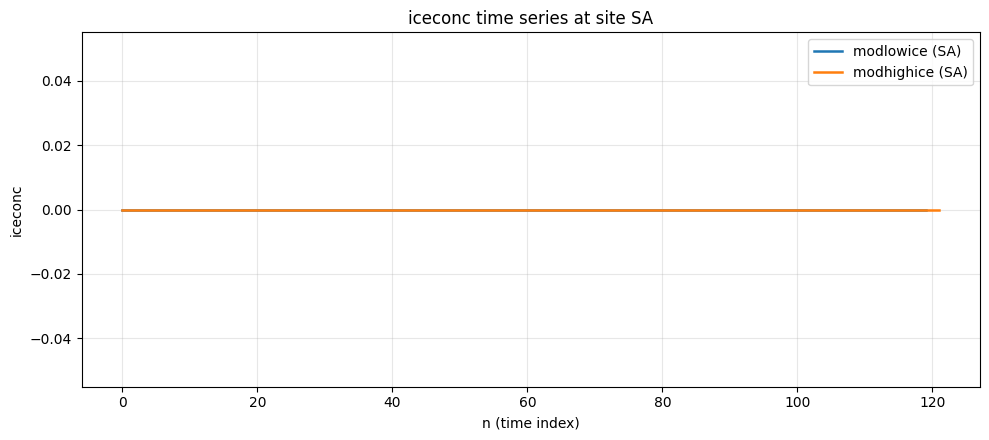

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Files
low_path = "../../training_data/emul_in_Y_modlowice_iceconc.nc"
high_path = "../../training_data/emul_in_Y_modhighice_iceconc.nc"

# Site indices from Make_site_txt.py (UK sea sites)
# site_lon_index_UK_sea = [-1, 1]
# site_lat_index_UK_sea = [16, 15]
# sitenameS = ["SA", "SB"]
sa_lat_idx = 16
sa_lon_idx = -1

# Load datasets
low_ds = xr.open_dataset(low_path)
high_ds = xr.open_dataset(high_path)

low_sa = low_ds["var"].isel(latitude=sa_lat_idx, longitude=sa_lon_idx).values
high_sa = high_ds["var"].isel(latitude=sa_lat_idx, longitude=sa_lon_idx).values

# Build x-axis using index of n dimension
x_low = np.arange(low_sa.shape[0])
x_high = np.arange(high_sa.shape[0])

plt.figure(figsize=(10, 4.5))
plt.plot(x_low, low_sa, label="modlowice (SA)", lw=1.8)
plt.plot(x_high, high_sa, label="modhighice (SA)", lw=1.8)
plt.xlabel("n (time index)")
plt.ylabel("iceconc")
plt.title("iceconc time series at site SA")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

low_ds.close()
high_ds.close()